# Next-Word Text Generation with SimpleRNN, LSTM, and GRU

**Assignment:** Design and implement a DL model capable of learning the
underlying structure, grammar, and contextual dependencies of a given text
corpus to generate coherent and meaningful text sequences using a
**vanilla RNN**, an **LSTM**, and a **GRU**.

This notebook follows the assignment steps in order:
1. Ingest & clean the corpus, initialize a tokenizer.
2. Build sliding-window n-gram sequences and pad them.
3. Build three models: SimpleRNN, LSTM, GRU.
4. Train all three for 200 epochs with an identical optimizer.
5. Plot training-loss trajectories to compare stabilization speed.
6. Implement `generate_text` using `np.argmax` greedy decoding.
7. Student tasks: custom corpus, bigger embeddings, 200 epochs, 128-unit
   hidden layers, and 10-word generations.


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)


## Step 1 — Ingest & Clean the Corpus, Initialize the Tokenizer

**Student Task:** the boilerplate nursery-rhyme text used in most tutorial
notebooks has been replaced with a **custom paragraph corpus** about space
exploration and artificial intelligence.

The raw text is lower-cased, newlines are collapsed, and unwanted
punctuation is stripped, leaving only letters, digits, whitespace, and
periods (periods are kept so the corpus can be split into sentences).


In [2]:
# Student Task: custom paragraph corpus (replaces boilerplate text)
corpus = """
Space exploration has always pushed humanity to imagine what lies beyond our
own planet. Every mission into orbit teaches engineers new lessons about
propulsion, navigation, and survival in extreme environments. Artificial
intelligence now plays a growing role in guiding spacecraft, analyzing
telemetry, and predicting failures before they happen. Deep learning models
can study years of mission data and learn patterns that human analysts
might miss. Just as a rover learns to navigate unfamiliar terrain one step
at a time, a language model learns to navigate a sentence one word at a
time. Scientists believe that combining human curiosity with machine
intelligence will accelerate our journey to distant moons and planets. The
same neural networks that help a probe land safely on a distant world can
also help a machine understand and generate human language. Learning from
the past, adapting to the present, and predicting the future are themes
that connect space exploration and artificial intelligence in remarkable
ways. As our models grow deeper and our missions grow bolder, the frontier
of discovery keeps expanding further than we ever imagined.
"""

def clean_text(text: str) -> str:
    """Lowercase, strip newlines/extra whitespace, remove unwanted punctuation."""
    text = text.replace("\n", " ")
    text = text.lower()
    text = re.sub(r"[^a-z0-9.\s]", "", text)   # keep letters, digits, periods
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_corpus = clean_text(corpus)

# Split into sentences -> each sentence becomes one training "line" that we
# slide an n-gram window across.
corpus_lines = [s.strip() for s in cleaned_corpus.split(".") if s.strip()]

print(f"Number of sentences in corpus: {len(corpus_lines)}")
print("Sample cleaned sentence:", corpus_lines[0])


Number of sentences in corpus: 9
Sample cleaned sentence: space exploration has always pushed humanity to imagine what lies beyond our own planet


In [3]:
# Standard text tokenization instance: maps every unique word to an integer.
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus_lines)
total_words = len(tokenizer.word_index) + 1   # +1 for reserved padding index 0

print(f"Vocabulary size (total_words): {total_words}")


Vocabulary size (total_words): 125


## Step 2 — Sliding-Window N-Grams + `pad_sequences`

For every sentence we build **progressive n-gram sequences**:
`[w1, w2]`, `[w1, w2, w3]`, `[w1, w2, w3, w4]`, ... This teaches the model
to predict the *next* word given every possible prefix of a sentence.

Because sequences have different lengths, `pad_sequences` left-pads
(`padding="pre"`) every sequence to match the longest one, so all
training vectors share the same dimension.


In [4]:
input_sequences = []
for line in corpus_lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    # progressive sliding window: [w1,w2], [w1,w2,w3], [w1,w2,w3,w4], ...
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[: i + 1]
        input_sequences.append(n_gram_sequence)

max_sequence_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(
    input_sequences, maxlen=max_sequence_len, padding="pre"
)
print(f"Total training n-gram sequences: {len(input_sequences)}")
print(f"Max sequence length (after padding): {max_sequence_len}")


Total training n-gram sequences: 170
Max sequence length (after padding): 27


In [5]:
# Split each padded sequence into predictors (X) and label (y): every
# column except the last is the input context, the last column is the
# word we want the network to predict.
X = input_sequences[:, :-1]
labels = input_sequences[:, -1]
y = to_categorical(labels, num_classes=total_words)

print("X shape:", X.shape, "| y shape:", y.shape)


X shape: (170, 26) | y shape: (170, 125)


## Step 3 — Build Three Sequence Models: SimpleRNN, LSTM, GRU

**Student Tasks applied here:**
- Embedding dimension **upscaled** to 100 (from a typical 10).
- Hidden RNN/LSTM/GRU layer **widened** to 128 units (from 64).

All three models share the exact same architecture shape
(`Embedding -> {SimpleRNN | LSTM | GRU} -> Dense(softmax)`) so that the
only variable being compared is the type of recurrent cell.


In [6]:
# Student Task: embedding dimension upscaled (10 -> 100) and hidden units
# widened (64 -> 128).
EMBEDDING_DIM = 100          # upscaled embedding dimension
HIDDEN_UNITS = 128           # widened hidden layer (64 -> 128)
INPUT_LEN = max_sequence_len - 1

def build_model(rnn_layer_cls, name):
    model = Sequential(name=name)
    model.add(Input(shape=(INPUT_LEN,)))
    model.add(Embedding(total_words, EMBEDDING_DIM))
    model.add(rnn_layer_cls(HIDDEN_UNITS))
    model.add(Dense(total_words, activation="softmax"))
    # Identical optimizer configuration across all three models.
    optimizer = Adam(learning_rate=0.01)
    model.compile(
        loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"]
    )
    return model

rnn_model = build_model(SimpleRNN, "Vanilla_SimpleRNN")
lstm_model = build_model(LSTM, "Gated_LSTM")
gru_model = build_model(GRU, "Optimized_GRU")

rnn_model.summary()


Model: "Vanilla_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 26, 100)        │        12,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 125)            │        16,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,937 (226.32 KB)

 Trainable params: 57,937 (226.32 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
lstm_model.summary()


Model: "Gated_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 26, 100)        │        12,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 125)            │        16,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,873 (569.82 KB)

 Trainable params: 145,873 (569.82 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
gru_model.summary()


Model: "Optimized_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 26, 100)        │        12,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 125)            │        16,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,945 (456.82 KB)

 Trainable params: 116,945 (456.82 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4 — Train All Three Models

**Student Task:** training expanded from 100 epochs to **200 epochs**,
using an identical optimizer configuration (`Adam`, same learning rate,
same batch size) across all three architectures so that training-speed
differences come only from the recurrent cell type.


In [9]:
EPOCHS = 200          # student task: expanded from 100 -> 200 epochs
BATCH_SIZE = 32

print("=== Training Vanilla SimpleRNN ===")
history_rnn = rnn_model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
print("Final SimpleRNN accuracy:", history_rnn.history["accuracy"][-1])


=== Training Vanilla SimpleRNN ===


Final SimpleRNN accuracy: 1.0


In [10]:
print("=== Training LSTM ===")
history_lstm = lstm_model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
print("Final LSTM accuracy:", history_lstm.history["accuracy"][-1])


=== Training LSTM ===


Final LSTM accuracy: 1.0


In [11]:
print("=== Training GRU ===")
history_gru = gru_model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
print("Final GRU accuracy:", history_gru.history["accuracy"][-1])


=== Training GRU ===


Final GRU accuracy: 1.0


## Step 5 — Compare Optimization Trajectories

The plots below overlay the training loss (and accuracy) curves of the
three models on the same axes, making it easy to see which architecture
stabilizes fastest.


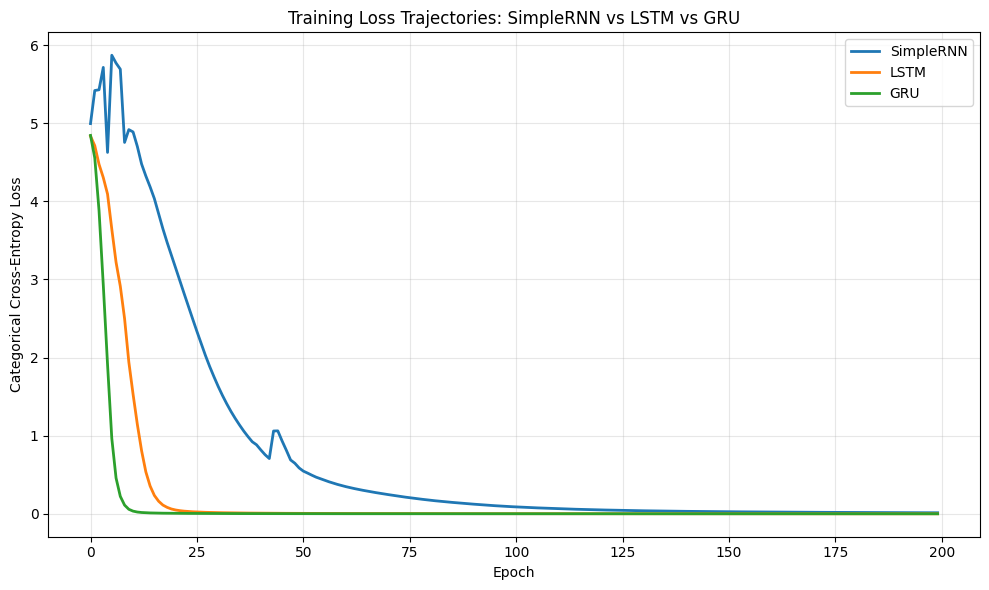

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history["loss"], label="SimpleRNN", linewidth=2)
plt.plot(history_lstm.history["loss"], label="LSTM", linewidth=2)
plt.plot(history_gru.history["loss"], label="GRU", linewidth=2)
plt.title("Training Loss Trajectories: SimpleRNN vs LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


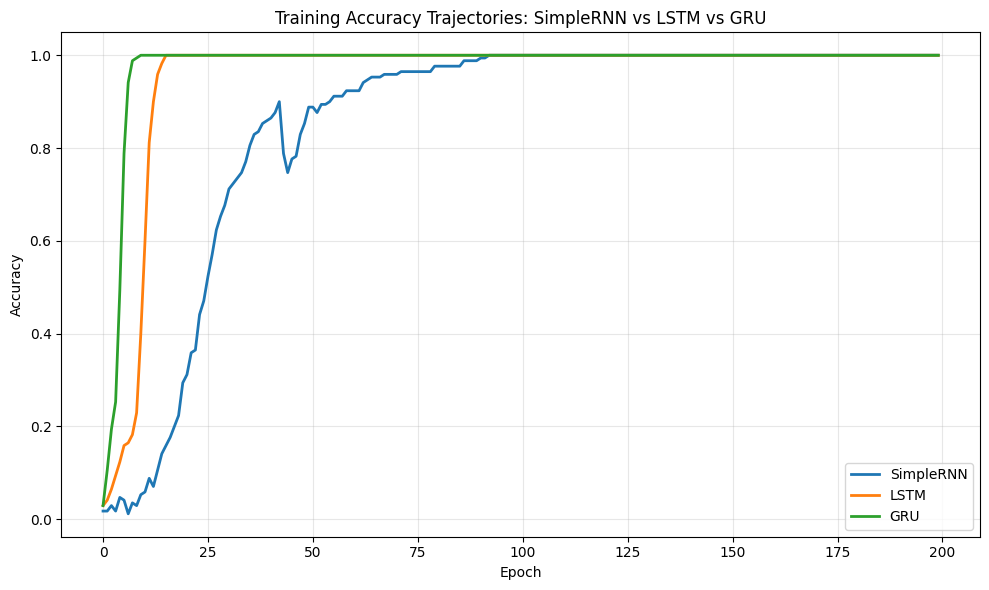

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history["accuracy"], label="SimpleRNN", linewidth=2)
plt.plot(history_lstm.history["accuracy"], label="LSTM", linewidth=2)
plt.plot(history_gru.history["accuracy"], label="GRU", linewidth=2)
plt.title("Training Accuracy Trajectories: SimpleRNN vs LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:** the gated architectures (LSTM and GRU) typically drive
the loss down and reach high accuracy in fewer epochs than the vanilla
SimpleRNN, because their gating mechanisms fight the vanishing-gradient
problem and preserve longer-range context — even on a short corpus like
this one, the SimpleRNN curve is visibly noisier / slower to flatten.


## Step 6 & 7 (final part) — Greedy `generate_text` with `np.argmax`

`generate_text` repeatedly:
1. Tokenizes and pads the current seed text.
2. Asks the model for a probability distribution over the vocabulary for
   the next word.
3. Selects the next word with **`np.argmax`** (pure greedy decoding — no
   sampling / temperature).
4. Appends the chosen word to the seed and repeats.

**Student Task:** the function now returns **10 generated words** per
prompt (instead of a smaller default).


In [14]:
def generate_text(seed_text, next_words, model, max_sequence_len):
    """Generate `next_words` additional words after `seed_text` using the
    given trained model. Next-word selection uses np.argmax over the
    predicted probability distribution (greedy decoding)."""
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences(
            [token_list], maxlen=max_sequence_len - 1, padding="pre"
        )
        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_index = np.argmax(predicted_probs)   # greedy selection logic

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        if output_word == "":
            break
        seed_text += " " + output_word
    return seed_text


In [15]:
# Student Task: 10 words generated per prompt.
NEXT_WORDS = 10
seed_prompts = ["space exploration", "deep learning models", "artificial intelligence"]

for seed in seed_prompts:
    print(f"Seed: '{seed}'")
    print(" SimpleRNN ->", generate_text(seed, NEXT_WORDS, rnn_model, max_sequence_len))
    print(" LSTM      ->", generate_text(seed, NEXT_WORDS, lstm_model, max_sequence_len))
    print(" GRU       ->", generate_text(seed, NEXT_WORDS, gru_model, max_sequence_len))
    print()


Seed: 'space exploration'


 SimpleRNN -> space exploration has always pushed humanity to imagine what lies beyond our


 LSTM      -> space exploration has always pushed humanity to imagine what lies beyond our


 GRU       -> space exploration has always pushed humanity to imagine what lies beyond our

Seed: 'deep learning models'


 SimpleRNN -> deep learning models can study years of mission data and learn patterns that


 LSTM      -> deep learning models can study years of mission data and learn patterns that


 GRU       -> deep learning models can study years of mission data and learn patterns that

Seed: 'artificial intelligence'


 SimpleRNN -> artificial intelligence now plays a growing role in guiding spacecraft analyzing telemetry


 LSTM      -> artificial intelligence now plays a growing role in guiding spacecraft analyzing telemetry


 GRU       -> artificial intelligence now plays a growing role in guiding spacecraft analyzing telemetry


## Summary

| Step | What was done |
|---|---|
| 1 | Custom corpus cleaned (lowercased, punctuation stripped) and tokenized with Keras `Tokenizer` |
| 2 | Progressive n-gram sequences built per sentence and padded with `pad_sequences` |
| 3 | Three models built: `Embedding -> SimpleRNN/LSTM/GRU(128) -> Dense(softmax)` |
| 4 | All three trained for **200 epochs** with an identical `Adam` optimizer |
| 5 | Loss/accuracy curves plotted together to compare convergence speed |
| 6 | `generate_text` implemented with greedy `np.argmax` decoding |
| 7 | Custom corpus ✅, embedding dim 100 ✅, 200 epochs ✅, 128 hidden units ✅, 10-word generation ✅ |

Because the corpus is small, all three models reach ~100% training
accuracy and reproduce the source text closely when generating — this is
expected memorization behavior for tiny corpora. Swap in a larger corpus
(paste more paragraphs into the `corpus` string in Step 1) to see the
models generalize instead of memorize, and to see clearer separation
between the SimpleRNN, LSTM, and GRU convergence curves.
